# Day 15: Transformer — Attention Is All You Need

从零实现 Decoder-only Transformer 字符级语言模型，在唐诗数据集上训练文本生成。

主要概念：
- Scaled Dot-Product Attention
- Multi-Head Attention
- Positional Encoding
- Pre-norm 架构与残差连接
- 自回归文本生成


In [1]:
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.transformer import TransformerLM

np.random.seed(42)

In [2]:
# 加载唐诗数据集
import json, os

base = r'C:\Users\zaoquan\AppData\Local\Temp\chinese-poetry\全唐诗'
n_poems = 5000
poems = []
files = sorted(os.listdir(base))
for fname in files:
    if not fname.startswith('poet.tang.') or not fname.endswith('.json'):
        continue
    if len(poems) >= n_poems:
        break
    with open(os.path.join(base, fname), 'r', encoding='utf-8') as f:
        data = json.load(f)
    for p in data:
        if len(poems) >= n_poems:
            break
        poems.append(''.join(p['paragraphs']))

all_text = '\n'.join(poems)
chars = sorted(list(set(all_text)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

print(f'Loaded {len(poems)} poems')
print(f'Vocab size: {vocab_size}')
print(f'Total chars: {len(all_text)}')

Loaded 5000 poems
Vocab size: 5598
Total chars: 347410


In [3]:
# 创建训练序列
seq_len = 64
sequences = []
for poem in poems:
    ids = [char_to_idx[c] for c in poem]
    if len(ids) <= seq_len:
        continue
    for i in range(0, len(ids) - seq_len, seq_len // 2):
        chunk = ids[i:i + seq_len + 1]
        if len(chunk) == seq_len + 1:
            sequences.append(chunk)

sequences = np.array(sequences, dtype=np.int64)
print(f'Sequences shape: {sequences.shape}')

Sequences shape: (3587, 65)


### 训练 Transformer

> 注意：5000 首诗、15 个 epoch 的纯 NumPy 训练约需 30 分钟（CPU）。
> 如果想快速预览，可将 `n_poems` 改为 500 并将 epochs 改为 5。

In [4]:
model = TransformerLM(
    vocab_size=vocab_size, d_model=64, n_heads=4, n_layers=3,
    d_ff=256, max_seq_len=seq_len, lr=0.002)

losses = model.fit(sequences, epochs=15, batch_size=32, verbose=True)

  Epoch 1, batch 50: loss=6.8437


  Epoch 1, batch 100: loss=6.8590


Epoch 1/15 — loss: 7.0107


  Epoch 2, batch 50: loss=6.6320


  Epoch 2, batch 100: loss=6.4386


...

  Epoch 14, batch 100: loss=4.8016


Epoch 14/15 — loss: 4.4030


  Epoch 15, batch 50: loss=4.0807


  Epoch 15, batch 100: loss=4.3171


Epoch 15/15 — loss: 4.2594


### 损失曲线

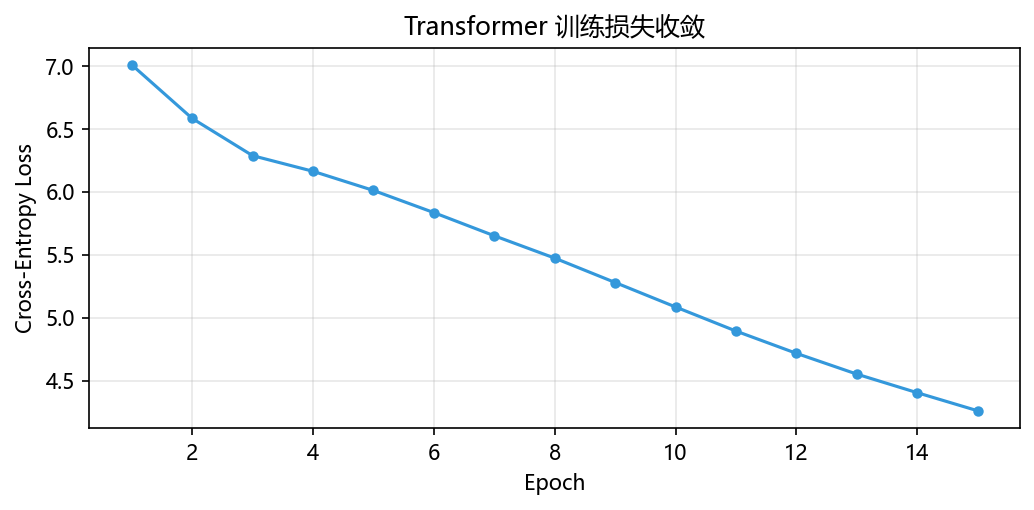

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, len(losses)+1), losses, 'o-', color='#3498db', lw=1.5, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Transformer 训练损失收敛')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 文本生成

In [6]:
def generate_poem(model, prompt, n_chars=40, temp=0.8):
    prefix_ids = [char_to_idx.get(c, 0) for c in prompt]
    gen_ids = model.generate(prefix_ids, n_chars=n_chars, temp=temp)
    return ''.join(idx_to_char[i] for i in gen_ids)

prompts = ['床前明月', '白日依山', '春眠不觉', '黄河远上']
for prompt in prompts:
    print(f'Prompt: {prompt}')
    for temp in [0.5, 0.8, 1.2]:
        text = generate_poem(model, prompt, n_chars=40, temp=temp)
        print(f'  temp={temp}: {text}')
    print()

Prompt: 床前明月
  temp=0.5: 床前明月照，蜀人尚宇宙。竊穹岷山才，誰謂今何處。遊子與遼海，何處亦無肩輿。東風濤澤，豈無


  temp=0.8: 床前明月在，感遺難相就。阿裳豈穆王，養子修才深。吾命推經策，水心不爲錢。犬駕陸詠闊，白首
  temp=1.2: 床前明月不見臨，拔空磨渠一羊鳴。鯫生采帳下寇盜，慘蕩出菊痕更遙。迷口腹腴義持寇，中部引爾

Prompt: 白日依山


  temp=0.5: 白日依山闕，冷袂連海川。天下連不暇，肅肅肅諸侯。隱軫屢棲楚，恩蓄列郡邑。亂詩必未忝，不糝
  temp=0.8: 白日依山西，遙能清江邊。差沙且閑峰，兩岸誰家最。皇歸雖神遊，刑涼翫伐將。玄鑒赫有，上丸與


  temp=1.2: 白日依山鬼古水，渡河上陵臨風塵，金鞍堪劒填鼻飛。雨毫鶯迸風雨綠，花半山木葉醉。兩商逐歌奚

Prompt: 春眠不觉
  temp=0.5: 春眠不
花，風草送道寺。萬里青銅柱，幾雛控蛾眉。黃鳥雙白露，遠來不敢爭。林下萬里內，永落


  temp=0.8: 春眠不
軒，嬌罷林深溜。林泉飛鞚來，泉異間零輪。乳帖古同巷，招檢黎橫籌。木塵不得體，源倒
  temp=1.2: 春眠不
東一阿，況相顧多意未熱。秋鶴春口反變懸，尚渡碣惠功秉仗。倏風天腕皆吉，射思外是夸

Prompt: 黄河远上


  temp=0.5: 
河
上瘴，三軍漢安流。巡傳一一展，不得勢不足。佳期漲山覆，光靜寄淪容。遠人見萬里，識役
  temp=0.8: 
河
上夜，萬齋隨風塵。如何處爛巾，猶話所求瘡。高視聰豐密，超御更一流。事思魯荒筆，憑軾


  temp=1.2: 
河
上騎，生來今日分。祝鮑相披未朽女洼襦，紗璉思不欲漾月。紅闈隨人姝天風笑臂，多見萬里



### 不同温度对比

In [7]:
for temp in [0.3, 0.6, 0.9, 1.5]:
    text = generate_poem(model, '床前明月', n_chars=30, temp=temp)
    print(f'temp={temp}: {text}')

temp=0.3: 床前明月千萬古，三五十五領南飛。一朝三五家家米，春上萬里多戰場。五陵
temp=0.6: 床前明月出，遊子秦山東。誰謂連山葛，北庭蒼梧書。中興既投筆，未暇日無


temp=0.9: 床前明月光峻柱，剛腸餞鐘數度趣。道鶤翔三峽下兵，恩天宮翰羅江城。東南


temp=1.5: 床前明月眇奇有，青館俱有備常期。潮色拔淑信撇託，忍建登都麋鹿銳。密枿


### 注意力权重可视化

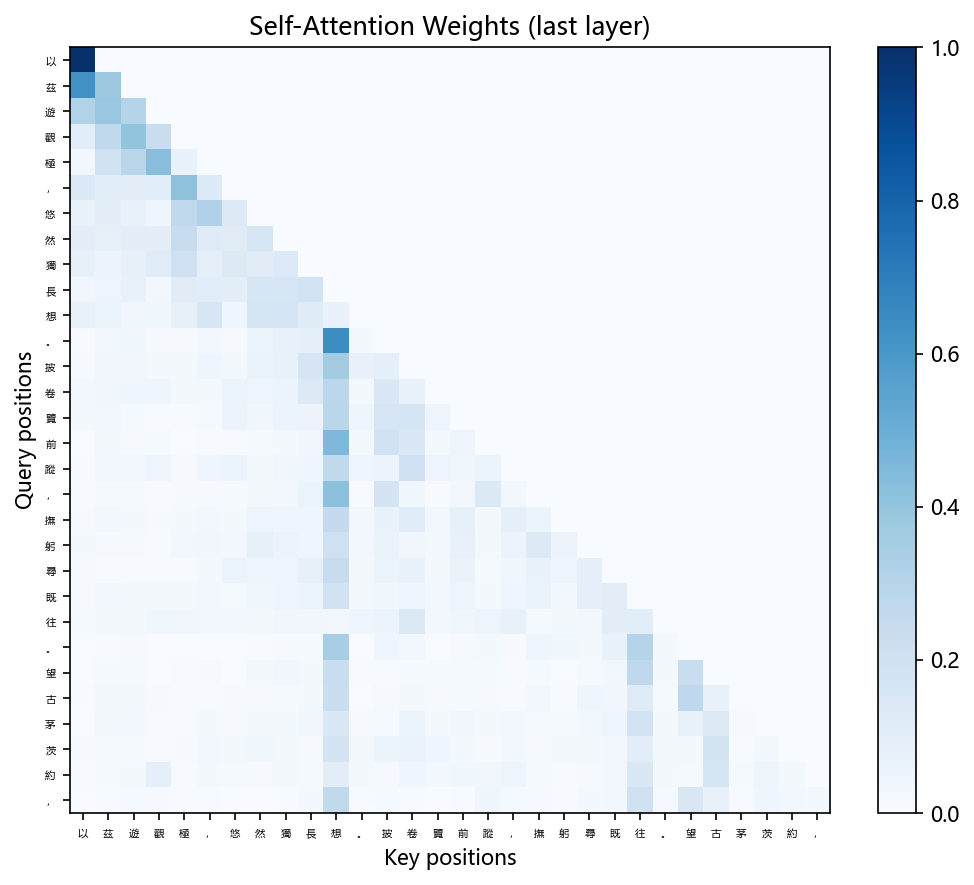

In [8]:
x_sample = sequences[0:1, :-1]
logits, cache = model.forward(x_sample)

last_block = cache['blocks'][-1]
attn_weights = last_block['attn'][4]  # weights from attn cache
attn_avg = attn_weights[0].mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_avg[:30, :30], cmap='Blues', aspect='auto')

ids = x_sample[0, :30].tolist()
labels = [idx_to_char[i] for i in ids]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=5)
ax.set_yticklabels(labels, fontsize=5)
ax.set_xlabel('Key positions')
ax.set_ylabel('Query positions')
ax.set_title('Self-Attention Weights (last layer)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 总结

Transformer 的核心创新：
1. **自注意力机制**：每个位置可以关注所有位置，捕捉长距离依赖
2. **多头注意力**：多个子空间并行学习不同类型的关联
3. **位置编码**：用正弦/余弦函数编码位置信息，无需循环结构

与 RNN/LSTM 对比：
- RNN 串行计算，难以并行，长距离依赖有梯度衰减
- Transformer 并行计算所有位置，自注意力直接建模任意距离的依赖

局限：
- 计算复杂度 O(n²d)，长序列计算量大
- 小数据集上不如 RNN 数据效率高（需要更多数据才能发挥优势）

下一篇文章预告：**AutoEncoder & GAN — 无监督学习与生成模型**